# **Ayudantía 4**

In [1]:
# cargamos sqlite3
# https://www.sqlite.org/docs.html
!pip install -q "ipython-sql" "prettytable==3.11.0"
%load_ext sql
#nos conectamos o creamos una base de datos (con :memory: la guardamos en ram)
%sql sqlite:///:memory:

In [2]:
 %reload_ext sql

## Restricciones en SQL (Constraints)

Las restricciones definen reglas sobre los datos que pueden almacenarse en una tabla.
Se aplican al momento de insertar, actualizar o eliminar registros.

---

### 1. `PRIMARY KEY`

Identifica de forma única cada fila de una tabla. No permite valores `NULL` ni duplicados.

```sql
CREATE TABLE Cliente (
    id_cliente INTEGER PRIMARY KEY
);
```
---

### 2. `NOT NULL`

Obliga a que una columna siempre tenga un valor; no acepta `NULL`.

```sql
CREATE TABLE Cliente (
    saldo INTEGER NOT NULL
);
```

> Nota: SQLite acepta string vacío `""` aunque la columna sea `NOT NULL`, porque `""` no es `NULL`.

---

### 3. `UNIQUE`

Garantiza que todos los valores de una columna (o combinación de columnas) sean distintos.
A diferencia de `PRIMARY KEY`, sí permite un valor `NULL` (en la mayoría de motores).

```sql
CREATE TABLE Cliente (
    direccion TEXT UNIQUE
);
```

---

### 4. `CHECK`

Valida que los valores cumplan una condición lógica antes de insertarse.

```sql
CREATE TABLE Cliente (
    descuento INTEGER NOT NULL CHECK(descuento >= 0 AND descuento <= 100),
    direccion TEXT NOT NULL CHECK(length(direccion) > 5 AND length(direccion) < 100)
);
```

Si la condición falla, se lanza un error.


#### Comparación
```sql
CHECK(saldo > 0)
CHECK(descuento >= 0 AND descuento <= 100)
CHECK(precio <> 0)
```

#### Lógicos
```sql
CHECK(descuento >= 0 AND descuento <= 100)
CHECK(saldo > 0 OR credito > 0)
CHECK(NOT saldo < 0)
```

#### `BETWEEN`
```sql
CHECK(descuento BETWEEN 0 AND 100)
```

#### `IN`
```sql
CHECK(estado IN ('activo', 'inactivo', 'suspendido'))
CHECK(tipo IN (1, 2, 3))
```

#### Funciones de texto
```sql
CHECK(length(direccion) > 5 AND length(direccion) < 100)
CHECK(nombre LIKE 'A%')
CHECK(email LIKE '%@%.%')
```

#### Funciones numéricas
```sql
CHECK(abs(saldo) < 100000)
CHECK(round(precio, 2) = precio)
```
---

### 5. `DEFAULT`

Asigna un valor automático cuando no se especifica uno al insertar.

```sql
CREATE TABLE Pedido (
    id_cliente INTEGER DEFAULT 1
);
```

---

### 6. `FOREIGN KEY`

Vincula una columna con la clave primaria de otra tabla.
Requiere que el valor exista en la tabla referenciada.

```sql
CREATE TABLE Pedido (
    id_cliente INTEGER,
    FOREIGN KEY(id_cliente) REFERENCES Cliente(id_cliente)
);
```

> En SQLite hay que activar las claves foráneas explícitamente:
> ```sql
> PRAGMA foreign_keys = ON;
> ```

---

### 7. Acciones referenciales (`ON DELETE` / `ON UPDATE`)

Definen qué pasa con las tuplas hijas cuando se elimina o actualiza la tupla padre.

| Acción | Efecto |
|---|---|
| `ON CASCADE` | Elimina/actualiza automáticamente las tuplas hijas |
| `SET NULL` | Pone `NULL` en la clave foránea de las hijas |
| `SET DEFAULT` | Pone el valor por defecto en la clave foránea |
| `RESTRICT` | Bloquea la operación si existen filas hijas |
| `NO ACTION` | Similar a `RESTRICT`, pero verificado al final de la transacción |

Ejemplo:
```sql
-- CASCADE: borra pedidos si se borra el cliente
FOREIGN KEY(id_cliente) REFERENCES Cliente(id_cliente) ON DELETE CASCADE

-- SET NULL: deja id_cliente en NULL si se borra el cliente
FOREIGN KEY(id_cliente) REFERENCES Cliente(id_cliente) ON DELETE SET NULL

-- SET DEFAULT: asigna -1 si se borra el cliente
FOREIGN KEY(id_cliente) REFERENCES Cliente(id_cliente) ON DELETE SET DEFAULT
```

---

### 8. Clave primaria compuesta

Cuando la clave primaria se forma con más de una columna, se declara al final de la tabla.

```sql
CREATE TABLE Manufacturados (
    id_articulo INTEGER,
    id_fabrica  INTEGER,
    PRIMARY KEY (id_articulo, id_fabrica)
);
```

## **P3.** Considerando el esquema relacional que se muestra a continuación. Cree las tablas en SQL. Puede adjuntar las restricciones en los atributos que estime conveniente.


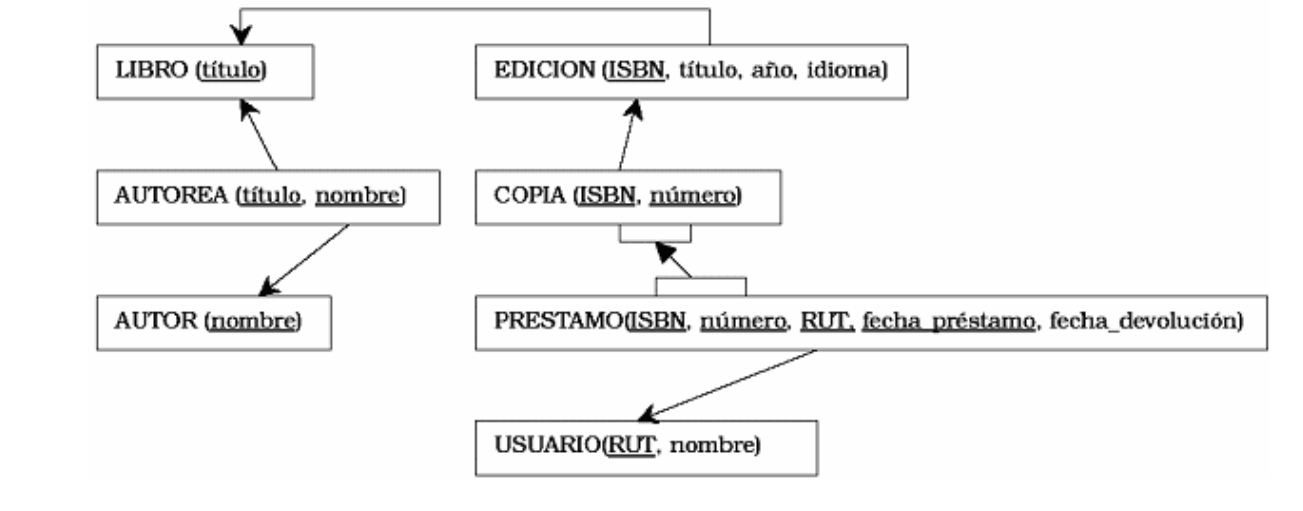

In [ ]:
%%sql
-- su código acá

In [ ]:
%%sql
-- Retorna 1 si las FK están activadas, 0 en caso contrario.
PRAGMA foreign_keys;

In [ ]:
%%sql
PRAGMA foreign_keys = ON;

In [ ]:
%%sql
-- Test de creación de tablas
SELECT name FROM sqlite_master WHERE type='table';

Para insertar valores:
```sql
%%sql
INSERT INTO Tabla VALUES (val1, val2...valK);
```
O podemos especificar los atributos:
```sql
%%sql
INSERT INTO Tabla (at1, at2...,atk) VALUES (val1, val2...valK);
```
**Cuidado que es acá cuando saltan los errores de las restricciones en los atributos.**

In [ ]:
%%sql
-- Verifiquemos que la tabla tiene datos
-- SELECT * FROM TABLA;